# 6.6 卷积神经网络（LeNet）
:label:`sec_lenet`

通过之前几节，我们学习了构建一个完整卷积神经网络的所需组件。
回想一下，之前我们将softmax回归模型（ :numref:`sec_softmax_scratch`）和多层感知机模型（ :numref:`sec_mlp_scratch`）应用于Fashion-MNIST数据集中的服装图片。
为了能够应用softmax回归和多层感知机，我们首先将每个大小为$28\times28$的图像展平为一个784维的固定长度的一维向量，然后用全连接层对其进行处理。
而现在，我们已经掌握了卷积层的处理方法，我们可以在图像中保留空间结构。
同时，用卷积层代替全连接层的另一个好处是：模型更简洁、所需的参数更少。

本节将介绍LeNet，它是最早发布的卷积神经网络之一，因其在计算机视觉任务中的高效性能而受到广泛关注。
这个模型是由AT&T贝尔实验室的研究员Yann LeCun在1989年提出的（并以其命名），目的是识别图像 :cite:`LeCun.Bottou.Bengio.ea.1998`中的手写数字。
当时，Yann LeCun发表了第一篇通过反向传播成功训练卷积神经网络的研究，这项工作代表了十多年来神经网络研究开发的成果。

当时，LeNet取得了与支持向量机（support vector machines）性能相媲美的成果，成为监督学习的主流方法。
LeNet被广泛用于自动取款机（ATM）机中，帮助识别处理支票的数字。
时至今日，一些自动取款机仍在运行Yann LeCun和他的同事Leon Bottou在上世纪90年代写的代码呢！

## 6.6.1 LeNet

总体来看，**LeNet（LeNet-5）由两个部分组成：**

* 卷积编码器：由两个卷积层组成;
* 全连接层密集块：由三个全连接层组成。

该架构如 :numref:`img_lenet`所示。

![LeNet中的数据流。输入是手写数字，输出为10种可能结果的概率。](../img/lenet.svg)
:label:`img_lenet`

每个卷积块中的基本单元是一个卷积层、一个sigmoid激活函数和平均汇聚层。请注意，虽然ReLU和最大汇聚层更有效，但它们在20世纪90年代还没有出现。每个卷积层使用$5\times 5$卷积核和一个sigmoid激活函数。这些层将输入映射到多个二维特征输出，通常同时增加通道的数量。第一卷积层有6个输出通道，而第二个卷积层有16个输出通道。每个$2\times2$池操作（步幅2）通过空间下采样将维数减少4倍。卷积的输出形状由批量大小、通道数、高度、宽度决定。

为了将卷积块的输出传递给稠密块，我们必须在小批量中展平每个样本。换言之，我们将这个四维输入转换成全连接层所期望的二维输入。这里的二维表示的第一个维度索引小批量中的样本，第二个维度给出每个样本的平面向量表示。LeNet的稠密块有三个全连接层，分别有120、84和10个输出。因为我们在执行分类任务，所以输出层的10维对应于最后输出结果的数量。

通过下面的LeNet代码，可以看出用深度学习框架实现此类模型非常简单。我们只需要实例化一个`Sequential`块并将需要的层连接在一起。

我们对原始模型做了一点小改动，去掉了最后一层的高斯激活。除此之外，这个网络与最初的LeNet-5一致。

下面，我们将一个大小为$28 \times 28$的单通道（黑白）图像通过LeNet。通过在每一层打印输出的形状，我们可以[**检查模型**]，以确保其操作与我们期望的 :numref:`img_lenet_vert`一致。

![LeNet 的简化版。](../img/lenet-vert.svg)
:label:`img_lenet_vert`


请注意，在整个卷积块中，与上一层相比，每一层特征的高度和宽度都减小了。
第一个卷积层使用2个像素的填充，来补偿$5 \times 5$卷积核导致的特征减少。
相反，第二个卷积层没有填充，因此高度和宽度都减少了4个像素。
随着层叠的上升，通道的数量从输入时的1个，增加到第一个卷积层之后的6个，再到第二个卷积层之后的16个。
同时，每个汇聚层的高度和宽度都减半。最后，每个全连接层减少维数，最终输出一个维数与结果分类数相匹配的输出。

## 6.6.2 模型训练

现在我们已经实现了LeNet，让我们看看[**LeNet在Fashion-MNIST数据集上的表现**]。

虽然卷积神经网络的参数较少，但与深度的多层感知机相比，它们的计算成本仍然很高，因为每个参数都参与更多的乘法。
通过使用GPU，可以用它加快训练。


为了进行评估，我们需要**对** 3.6节中描述的 **`evaluate_accuracy`函数进行轻微的修改**.
由于完整的数据集位于内存中，因此在模型使用GPU计算数据集之前，我们需要将其复制到显存中。


**为了使用GPU，我们还需要一点小改动**
与 3.6节中定义的`train_epoch_ch3`不同，在进行正向和反向传播之前，我们需要将每一小批量数据移动到我们指定的设备（例如GPU）上。

如下所示，训练函数`train_ch6`也类似于 3.6节中定义的`train_ch3`。
由于我们将实现多层神经网络，因此我们将主要使用高级API。
以下训练函数假定从高级API创建的模型作为输入，并进行相应的优化。
我们使用在 5.2节中介绍的Xavier随机初始化模型参数。
与全连接层一样，我们使用交叉熵损失函数和小批量随机梯度下降。


In [1]:
!pip install d2l --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 4.8 MB/s eta 0:00:00


In [2]:
import os
import shutil
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
from d2l import torch as d2l

In [20]:
def load_data_fashion_mnist(batch_size, resize=None, num_workers=4):
    # 工作目录下的数据根（torchvision 会在 /kaggle/working 下创建 FashionMNIST 文件夹）
    work_root = "/kaggle/working"
    work_data_dir = os.path.join(work_root, "FashionMNIST")
    
    # 永久数据集目录（如果用户已上传）
    persistent_data_dir = "/kaggle/input/FashionMNIST"
    
    # 辅助函数：检查数据是否已存在且有效（包含 raw 或 processed 子目录）
    def is_data_valid(path):
        return os.path.exists(path) and (
            os.path.exists(os.path.join(path, "raw")) or
            os.path.exists(os.path.join(path, "processed"))
        )
    
    # 如果工作目录下已有有效数据，直接使用
    if is_data_valid(work_data_dir):
        print("数据已存在于工作目录，直接加载。")
    else:
        # 检查永久数据集是否存在
        if is_data_valid(persistent_data_dir):
            print("从永久数据集复制到工作目录...")
            # 如果工作目录下已有目录（可能为空），先删除
            if os.path.exists(work_data_dir):
                shutil.rmtree(work_data_dir)
            # 复制永久数据集到工作目录
            shutil.copytree(persistent_data_dir, work_data_dir)
            print("复制完成。")
        else:
            print("未找到永久数据集，将从网络下载到工作目录。")
            print("下载中...")
            # 临时下载到工作目录，torchvision 会在 work_root 下创建 FashionMNIST
            trans_dummy = transforms.Compose([transforms.ToTensor()])
            # 下载训练集，仅触发下载
            _ = torchvision.datasets.FashionMNIST(
                root=work_root, train=True, transform=trans_dummy, download=True)
            print("下载完成。")
            print("="*60)
            print("请将以下文件夹上传为 Kaggle 数据集，并附加到本 Notebook：")
            print(f"  路径: {work_data_dir}")
            print("上传后，下次运行时将自动从永久数据集复制，避免重复下载。")
            print("="*60)
    
    # 数据预处理
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    
    # 加载数据集（此时工作目录下已有数据）
    mnist_train = torchvision.datasets.FashionMNIST(
        root=work_root, train=True, transform=trans, download=False)
    mnist_test = torchvision.datasets.FashionMNIST(
        root=work_root, train=False, transform=trans, download=False)
    
    # 创建 DataLoader
    train_loader = DataLoader(
        mnist_train, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(
        mnist_test, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True)
    
    return train_loader, test_loader

In [2]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),  # 28-5+2*2+1=28  6通道,1*6*28*28
    nn.AvgPool2d(kernel_size=2, stride=2),  #(28-2+2)/2=14
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(), #14-5+1=10  6个批量,每个批量16个通道,1*16*10*10
    nn.AvgPool2d(kernel_size=2, stride=2),  #(10-2+2)/2=5
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

In [3]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [5]:
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 268kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]


In [6]:
def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [7]:
#@save
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec \n'
          f'total time {timer.sum():.2f}sec  '
          f'on {str(device)}')

现在，我们[**训练和评估LeNet-5模型**]。


50 epochs:
loss 0.257, train acc 0.903, test acc 0.879
40626.1 examples/sec on cuda:0

In [39]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),  # 28-5+2*2+1=28  6通道,1*6*28*28
    nn.AvgPool2d(kernel_size=2, stride=2),  #(28-2+2)/2=14
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(), #14-5+1=10  6个批量,每个批量16个通道,1*16*10*10
    nn.AvgPool2d(kernel_size=2, stride=2),  #(10-2+2)/2=5
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

loss 0.406, train acc 0.849, test acc 0.833
8447.7 examples/sec 
total time 106.54sec  on cpu


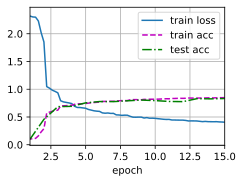

In [40]:
net = nn.DataParallel(net)          # 将模型包装为多GPU模式
device = torch.device('cuda')
lr, num_epochs = 0.9, 15
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

## 小结

* 卷积神经网络（CNN）是一类使用卷积层的网络。
* 在卷积神经网络中，我们组合使用卷积层、非线性激活函数和汇聚层。
* 为了构造高性能的卷积神经网络，我们通常对卷积层进行排列，逐渐降低其表示的空间分辨率，同时增加通道数。
* 在传统的卷积神经网络中，卷积块编码得到的表征在输出之前需由一个或多个全连接层进行处理。
* LeNet是最早发布的卷积神经网络之一。

## 练习

1. 将平均汇聚层替换为最大汇聚层，会发生什么？
1. 尝试构建一个基于LeNet的更复杂的网络，以提高其准确性。
    1. 调整卷积窗口大小。
    1. 调整输出通道的数量。
    1. 调整激活函数（如ReLU）。
    1. 调整卷积层的数量。
    1. 调整全连接层的数量。
    1. 调整学习率和其他训练细节（例如，初始化和轮数）。
1. 在MNIST数据集上尝试以上改进的网络。
1. 显示不同输入（例如毛衣和外套）时，LeNet第一层和第二层的激活值。

[Discussions](https://discuss.d2l.ai/t/1860)


```python
net = nn.DataParallel(net)          # 将模型包装为多GPU模式
device = torch.device('cuda')
```

### 1.最大汇聚层

loss 0.352, train acc 0.869, test acc 0.851
17547.9 examples/sec 
total time 51.29sec  on cuda


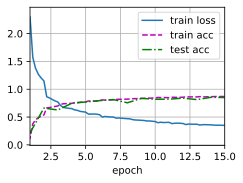

In [33]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),  # 28-5+2*2+1=28  6通道,1*6*28*28
    nn.MaxPool2d(kernel_size=2, stride=2),  #(28-2+2)/2=14
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(), #14-5+1=10  6个批量,每个批量16个通道,1*16*10*10
    nn.MaxPool2d(kernel_size=2, stride=2),  #(10-2+2)/2=5
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))
net = nn.DataParallel(net)          # 将模型包装为多GPU模式
device = torch.device('cuda')
lr, num_epochs = 0.9, 15
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

相比平均汇聚,相同训练轮数等超参数下,准确率上升

### 2.尝试改变网络结构

#### 1.使用ReLU

loss 0.234, train acc 0.911, test acc 0.895
17555.2 examples/sec 
total time 51.27sec  on cuda


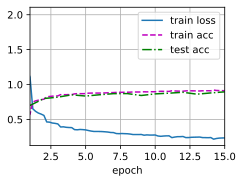

In [34]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),  # 28-5+2*2+1=28  6通道,1*6*28*28
    nn.MaxPool2d(kernel_size=2, stride=2),  #(28-2+2)/2=14
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(), #14-5+1=10  6个批量,每个批量16个通道,1*16*10*10
    nn.MaxPool2d(kernel_size=2, stride=2),  #(10-2+2)/2=5
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

net = nn.DataParallel(net)          # 将模型包装为多GPU模式
device = torch.device('cuda')       # 或使用 d2l.try_gpu(0)，DataParallel会接管所有GP
print("可用GPU数量:", torch.cuda.device_count())
lr, num_epochs = 0.9, 15
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

相比Sigmoid,相同训练轮数等超参数下,准确率上升

#### 2.调整卷积窗口,输出通道
<del>猜想: 卷积窗口变大,训练应该会变慢,精度会增加,至少train_acc是</del>  
- kernel_size=7 每秒处理的样本数增加,总时间变短,过拟合程度有所增加(train_acc没有上升,test_acc有所下降)
  >loss 0.234, train acc 0.913, test acc 0.863  
  >19384.1 examples/sec &ensp;&ensp; total time 46.43sec  on cuda

- kernel_size=3
  >loss 0.253, train acc 0.906, test acc 0.843  
  >17528.9 examples/sec &ensp;&ensp; total time 51.34sec  on cuda

- **kernel_size=5 最佳**
  >loss 0.224, train acc 0.916, test acc 0.892  
  >17478.7 examples/sec &ensp;&ensp; total time 51.49sec  on cuda

y

loss 0.234, train acc 0.915, test acc 0.906
5370.3 examples/sec 
total time 558.63sec  on cpu
可用GPU数量: 0


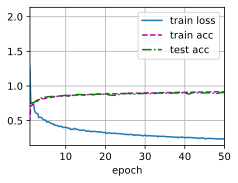

In [9]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),  # 28-5+2*2+1=28 
    nn.MaxPool2d(kernel_size=2, stride=2),  #(28-2+2)/2=14
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(), #14-5+1=10 
    nn.MaxPool2d(kernel_size=2, stride=2),  #(10-2+2)/2=5
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.ReLU(),nn.Dropout(0.3),
    nn.Linear(120, 84), nn.ReLU(),nn.Dropout(0.5),
    nn.Linear(84, 10))

#net = nn.DataParallel(net)          # 将模型包装为多GPU模式,无gpu会报错
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lr, num_epochs = 0.1, 50
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)
print("可用GPU数量:", torch.cuda.device_count())

*使用了两块 gpu ,所以examples/sec接近减半*

猜想: 输出通道增加,训练损失会下降
- 8+16个通道:  loss 0.210, train acc 0.921, test acc 0.882 17398.1 examples/sec 
total time 51.73sec  on cuda
- 4+16个通道: loss 0.239, train acc 0.911, test acc 0.868 17437.4 examples/sec 
total time 51.61sec  on cuda
- 10+20 个通道: loss 0.222, train acc 0.916, test acc 0.888 17123.7 examples/sec 
total time 52.56sec  on cuda
----

- 11+11: loss 0.227, train acc 0.916, test acc 0.888
通道数并没有显著影响?

In [47]:
def train_ch6_withoutPIC(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()

    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec \n'
          f'total time {timer.sum():.2f}sec  '
          f'on {str(device)}')

保持输出通道总和为22,遍历了 11-11 到 1-21 的结果
```python
for i in range(11):
    o1=11-i
    o2=11+i
    print(f'out chanel 1:{o1}  out chanel 2:{o2}')
    net = nn.Sequential(
    nn.Conv2d(1, o1, kernel_size=5, padding=2), nn.ReLU(),  # 28-5+2*2+1=28 
    nn.MaxPool2d(kernel_size=2, stride=2),  #(28-2+2)/2=14
    nn.Conv2d(o1, o2, kernel_size=5), nn.ReLU(), #14-5+1=10 
    nn.MaxPool2d(kernel_size=2, stride=2),  #(10-2+2)/2=5
    nn.Flatten(),
    nn.Linear(o2 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))
    
    net = nn.DataParallel(net)          # 将模型包装为多GPU模式
    device = torch.device('cuda')       # 或使用 d2l.try_gpu(0)，DataParallel会接管所有GP

    lr, num_epochs = 0.9, 15
    train_ch6_withoutPIC(net, train_iter, test_iter, num_epochs, lr, device)
    print('\n')
```
----
out chanel 1:11  out chanel 2:11
training on cuda
loss 0.233, train acc 0.912, test acc 0.893
17324.6 examples/sec 
total time 51.95sec  on cuda


out chanel 1:10  out chanel 2:12
training on cuda
loss 0.235, train acc 0.911, test acc 0.891
17250.3 examples/sec 
total time 52.17sec  on cuda


out chanel 1:9  out chanel 2:13
training on cuda
loss 0.227, train acc 0.915, test acc 0.895
17133.5 examples/sec 
total time 52.53sec  on cuda


out chanel 1:8  out chanel 2:14
training on cuda
loss 0.233, train acc 0.913, test acc 0.875
17388.6 examples/sec 
total time 51.76sec  on cuda


out chanel 1:7  out chanel 2:15
training on cuda
loss 0.236, train acc 0.911, test acc 0.885
17308.4 examples/sec 
total time 52.00sec  on cuda


out chanel 1:6  out chanel 2:16
training on cuda
loss 0.228, train acc 0.914, test acc 0.885
17438.9 examples/sec 
total time 51.61sec  on cuda


out chanel 1:5  out chanel 2:17
training on cuda
loss 0.223, train acc 0.917, test acc 0.875
17543.1 examples/sec 
total time 51.30sec  on cuda


out chanel 1:4  out chanel 2:18
training on cuda
loss 0.234, train acc 0.911, test acc 0.856
17503.2 examples/sec 
total time 51.42sec  on cuda


out chanel 1:3  out chanel 2:19
training on cuda
loss 0.229, train acc 0.915, test acc 0.879
17541.0 examples/sec 
total time 51.31sec  on cuda


out chanel 1:2  out chanel 2:20
training on cuda
loss 0.262, train acc 0.902, test acc 0.862
17444.2 examples/sec 
total time 51.59sec  on cuda


out chanel 1:1  out chanel 2:21
training on cuda
loss 0.265, train acc 0.899, test acc 0.858
17838.9 examples/sec 
total time 50.45sec  on cuda



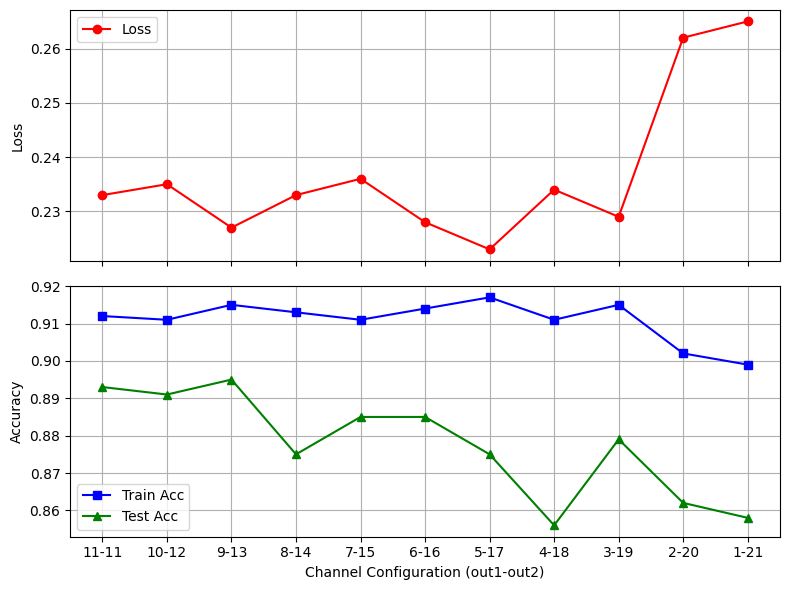

In [1]:
import matplotlib.pyplot as plt

# 提取的数据（按文本顺序）
loss = [0.233, 0.235, 0.227, 0.233, 0.236, 0.228, 0.223, 0.234, 0.229, 0.262, 0.265]
train_acc = [0.912, 0.911, 0.915, 0.913, 0.911, 0.914, 0.917, 0.911, 0.915, 0.902, 0.899]
test_acc = [0.893, 0.891, 0.895, 0.875, 0.885, 0.885, 0.875, 0.856, 0.879, 0.862, 0.858]

# 可选的 x 轴标签（通道配置）
configs = [
    "11-11", "10-12", "9-13", "8-14", "7-15",
    "6-16", "5-17", "4-18", "3-19", "2-20", "1-21"
]

# 创建子图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# 损失图
ax1.plot(configs, loss, marker='o', color='red', label='Loss')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# 准确率图
ax2.plot(configs, train_acc, marker='s', label='Train Acc', color='blue')
ax2.plot(configs, test_acc, marker='^', label='Test Acc', color='green')
ax2.set_xlabel('Channel Configuration (out1-out2)')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#### 3. 调整卷积层的数量

In [16]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),  # 28-5+2*2+1=28 
    nn.MaxPool2d(kernel_size=2, stride=2),  #(28-2+2)/2=14
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(), #14-5+1=10 
    nn.MaxPool2d(kernel_size=2, padding=1,stride=2),  #(10-2+1*2+2)/2=6
    nn.Conv2d(16, 32, kernel_size=3), nn.ReLU(), #6-3+1=4
    nn.MaxPool2d(kernel_size=2, stride=2), # (4-2+2)/2=2
    nn.Flatten(),
    nn.Linear(32 * 2 * 2, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

net = nn.DataParallel(net)          # 将模型包装为多GPU模式
device = torch.device('cuda')       # 或使用 d2l.try_gpu(0)，DataParallel会接管所有GP

loss 0.263, train acc 0.901, test acc 0.882
15083.7 examples/sec 
total time 59.67sec  on cuda


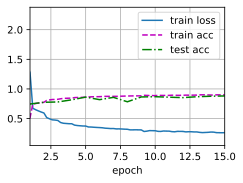

In [17]:
lr, num_epochs = 0.9, 15
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

In [28]:
import torch
from torch import nn
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

def tensor_to_PILimage(net: nn.Module, 
                       train_iter: DataLoader | torch.Tensor,
                       tensor_index: int=0,
                       columns: int=8,
                       figsize: tuple=(2,2),
                      ) -> None:
    '''
    tensor_index: the index of the tensor to choose
    columns: the number of plots in one row
    figsize: tuple of (width,height)
    '''

    if isinstance(train_iter,DataLoader):
        X=train_iter.dataset[tensor_index][0]
        #y=train_iter.dataset[tensor_index][1]
    elif isinstance(train_iter,torch.Tensor):
        X=train_iter
    else:
        raise "Wrong train_iter"

    if isinstance(net,nn.DataParallel):
        net=net.module.cpu()
        
    plot_width,plot_height=figsize
    fig, axes = plt.subplots(1, 1, figsize=(2, 2))
    image_X=ToPILImage()(X)
    axes.imshow(image_X)
    
    layer=0
    y_hat=net[layer](X)
    to_pil=ToPILImage()
    while not isinstance(net[layer],nn.Flatten):
        chanel=y_hat.shape[0]
        #height=y_hat.shape[1]
        #width=y_hat.shape[2]
        row=int((chanel-0.9)//columns+1)  #否则恰好整除时会多 1 
        fig, axes = plt.subplots(row, columns,
                                 figsize=(plot_width*columns, plot_height*row))
        for i in range(chanel):
            image = to_pil(y_hat[[i]])
            if row==1:
                axes[i].imshow(image)
                axes[0].set(title=f'net{layer} '+type(net[layer]).__name__)
            else:
                axes[i//columns,i%columns].imshow(image) #实际上是灰度的,是matplotlib带了颜色
                axes[0,0].set(title=f'net{layer} '+type(net[layer]).__name__)
        layer+=1
        y_hat=net[layer](y_hat)


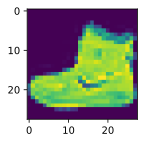

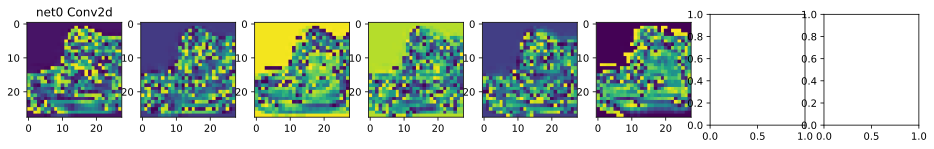

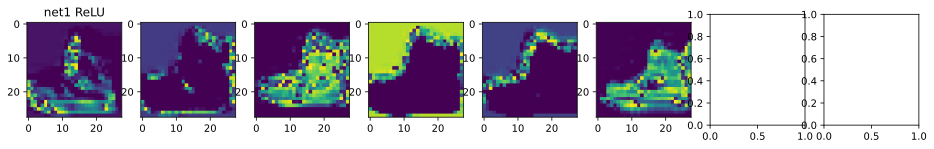

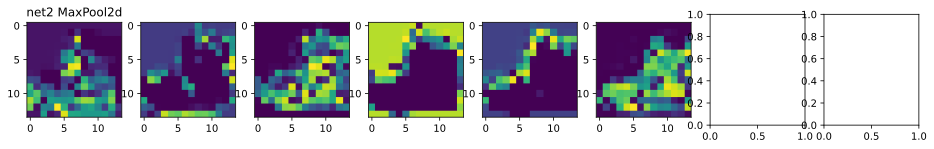

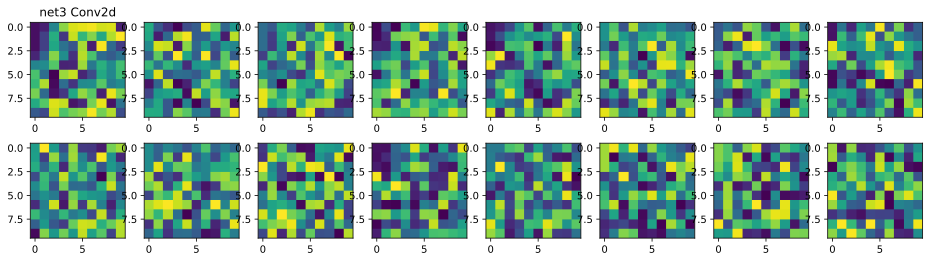

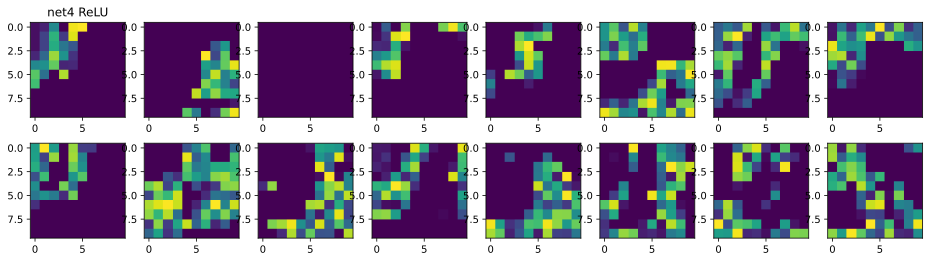

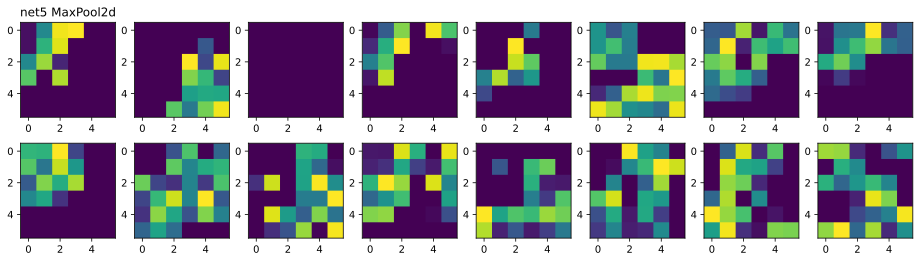

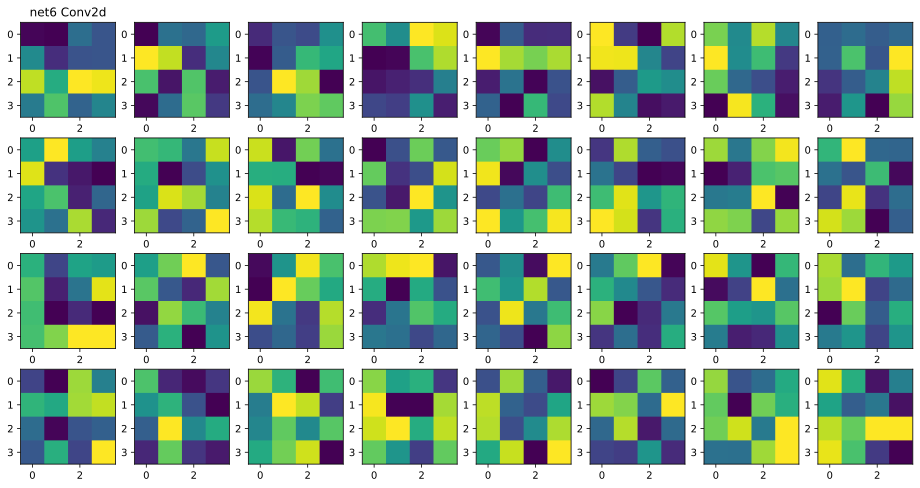

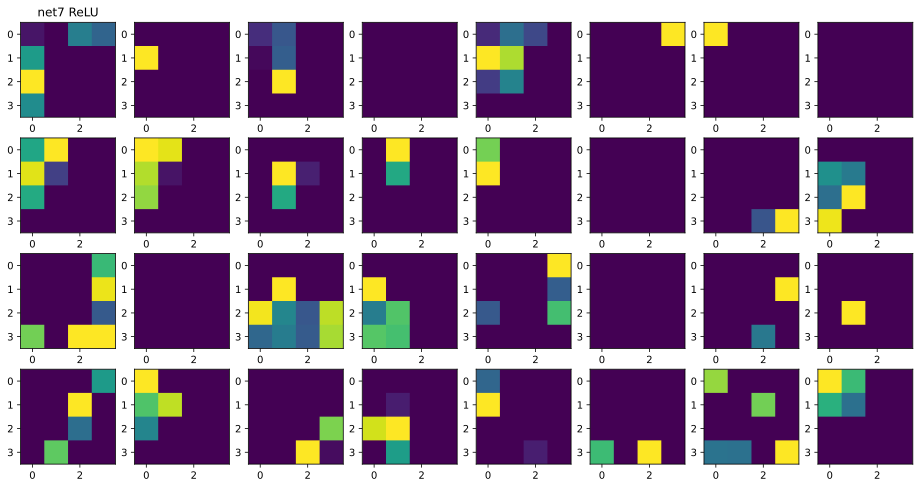

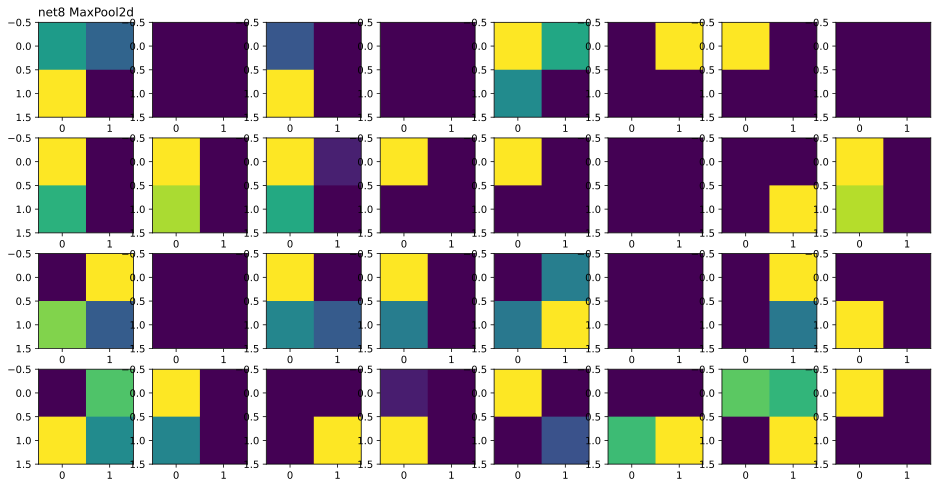

In [29]:
tensor_to_PILimage(net,train_iter)

loss 0.330, train acc 0.875, test acc 0.832
19057.6 examples/sec 
total time 47.23sec  on cuda
可用GPU数量: 2


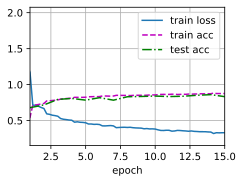

In [30]:
net = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=5, padding=2,stride=3), nn.ReLU(),  # (28-5+2*2+3)/3=10 
    nn.MaxPool2d(kernel_size=2, stride=2),  #(10-2+2)/2=5
    nn.Flatten(),
    nn.Linear(8 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

net = nn.DataParallel(net)          # 将模型包装为多GPU模式
device = torch.device('cuda')       # 或使用 d2l.try_gpu(0)，DataParallel会接管所有GP

lr, num_epochs = 0.9, 15
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)
print("可用GPU数量:", torch.cuda.device_count())

test_acc很低

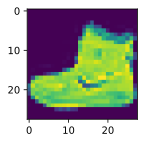

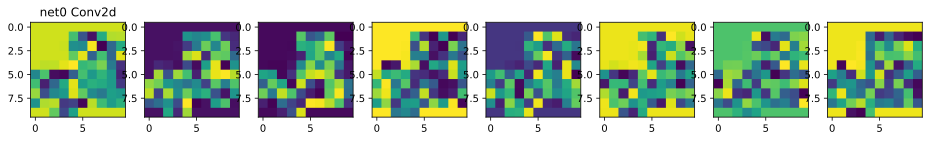

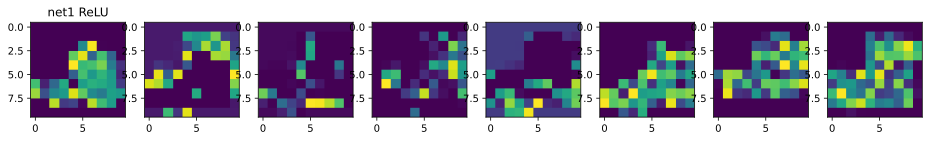

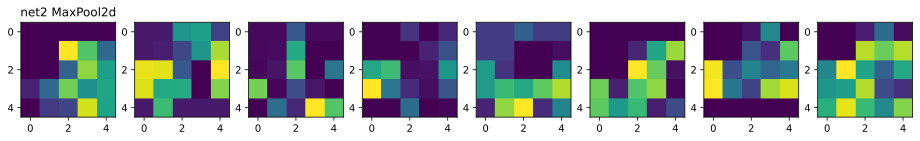

In [31]:
tensor_to_PILimage(net, train_iter)

 目前最优是 原本的LeNet+ReLu+MaxPool2d  
 loss 0.224, train acc 0.916, test acc 0.892
17478.7 examples/sec 
total time 51.49sec  on cuda
 

#### 4.调整线性部分

将线性部分的 Sigmoid 换成了 ReLU,训练完全没反应 lr=0.9   
需要降低学习率

## 7.5 使用批量规范化

In [3]:
def load_data_fashion_mnist(batch_size, resize=None, num_workers=4):
    # 工作目录下的数据根（torchvision 会在 /kaggle/working 下创建 FashionMNIST 文件夹）
    work_root = "/kaggle/working"
    work_data_dir = os.path.join(work_root, "FashionMNIST")
    
    # 永久数据集目录（如果用户已上传）
    persistent_data_dir = "/kaggle/input/FashionMNIST"
    
    # 辅助函数：检查数据是否已存在且有效（包含 raw 或 processed 子目录）
    def is_data_valid(path):
        return os.path.exists(path) and (
            os.path.exists(os.path.join(path, "raw")) or
            os.path.exists(os.path.join(path, "processed"))
        )
    
    # 如果工作目录下已有有效数据，直接使用
    if is_data_valid(work_data_dir):
        print("数据已存在于工作目录，直接加载。")
    else:
        # 检查永久数据集是否存在
        if is_data_valid(persistent_data_dir):
            print("从永久数据集复制到工作目录...")
            # 如果工作目录下已有目录（可能为空），先删除
            if os.path.exists(work_data_dir):
                shutil.rmtree(work_data_dir)
            # 复制永久数据集到工作目录
            shutil.copytree(persistent_data_dir, work_data_dir)
            print("复制完成。")
        else:
            print("未找到永久数据集，将从网络下载到工作目录。")
            print("下载中...")
            # 临时下载到工作目录，torchvision 会在 work_root 下创建 FashionMNIST
            trans_dummy = transforms.Compose([transforms.ToTensor()])
            # 下载训练集，仅触发下载
            _ = torchvision.datasets.FashionMNIST(
                root=work_root, train=True, transform=trans_dummy, download=True)
            print("下载完成。")
            print("="*60)
            print("请将以下文件夹上传为 Kaggle 数据集，并附加到本 Notebook：")
            print(f"  路径: {work_data_dir}")
            print("上传后，下次运行时将自动从永久数据集复制，避免重复下载。")
            print("="*60)
    
    # 数据预处理
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    
    # 加载数据集（此时工作目录下已有数据）
    mnist_train = torchvision.datasets.FashionMNIST(
        root=work_root, train=True, transform=trans, download=False)
    mnist_test = torchvision.datasets.FashionMNIST(
        root=work_root, train=False, transform=trans, download=False)
    
    # 创建 DataLoader
    train_loader = DataLoader(
        mnist_train, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(
        mnist_test, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True)
    
    return train_loader, test_loader

In [4]:
def load_data_fashion_mnist_in_memory(batch_size, resize=None, num_workers=4):
    work_root = "/kaggle/working"
    
    # 先下载/加载数据（不生成DataLoader）
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    
    train_data = torchvision.datasets.FashionMNIST(
        root=work_root, train=True, transform=trans, download=True)
    test_data = torchvision.datasets.FashionMNIST(
        root=work_root, train=False, transform=trans, download=True)
    
    # 将数据转换为Tensor并存入内存
    X_train = torch.stack([img for img, _ in train_data])
    y_train = torch.tensor([label for _, label in train_data])
    X_test = torch.stack([img for img, _ in test_data])
    y_test = torch.tensor([label for _, label in test_data])
    
    # 创建TensorDataset
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    test_dataset = torch.utils.data.TensorDataset(X_test, y_test)
    
    # 此时DataLoader不再需要磁盘I/O，worker只需从内存读取
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader

In [5]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """Train a model with a GPU (defined in Chapter 6).

    Defined in :numref:`sec_utils`"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec \n'
          f'total time {timer.sum():.4f}sec '
          f'on {str(device)}')

In [6]:
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist_in_memory(batch_size=batch_size)

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.13MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 65.3MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.53MB/s]


In [58]:
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10),
)

loss 0.204, train acc 0.924, test acc 0.891
55385.3 examples/sec 
total time 21.6664sec on cuda


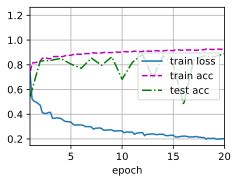

In [59]:
# 单个GPU耗时22.13秒
# 在这种任务简单,每个GPU的占用都不高时,多个GPU反而会更慢
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

### 1.在使用批量规范化之前，我们是否可以从全连接层或卷积层中删除偏置参数？
为什么？  

从结果来看,不可以,虽然训练误差和有偏置时差别不大. 但是**泛化能力降低**.

In [45]:
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, bias=False), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5, bias=False), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120, bias=False), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84, bias=False), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10),
)

loss 0.199, train acc 0.926, test acc 0.829
56512.3 examples/sec 
total time 21.2343sec on cuda


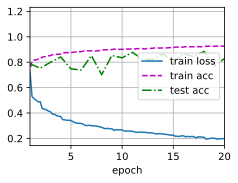

In [46]:
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

### 2.可以通过批量规范化来替换暂退法吗？行为会如何改变？  
感觉不可以,很明显可以看到使用BN之后test acc波动很大,很不稳定,而加上dropout之后test acc波动会减小

In [60]:
# 同时使用批量规范化和暂退法
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120),nn.Dropout(0.5), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84),nn.Dropout(0.5), nn.Sigmoid(),
    nn.Linear(84, 10),
)

loss 0.301, train acc 0.895, test acc 0.866
53972.2 examples/sec 
total time 22.2337sec on cuda


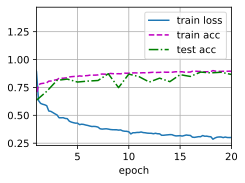

In [53]:
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

In [61]:
# 只使用暂退法
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120),nn.Dropout(0.5), nn.Sigmoid(),
    nn.Linear(120, 84),nn.Dropout(0.5), nn.Sigmoid(),
    nn.Linear(84, 10),
)

loss 0.380, train acc 0.872, test acc 0.805
57714.5 examples/sec 
total time 20.7920sec on cuda


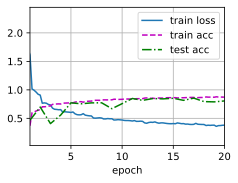

In [55]:
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

In [62]:
# ReLU牛逼
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120),nn.Dropout(0.5), nn.ReLU(),
    nn.Linear(120, 84), nn.BatchNorm1d(84),nn.Dropout(0.5), nn.ReLU(),
    nn.Linear(84, 10),
)

loss 0.289, train acc 0.898, test acc 0.892
54731.3 examples/sec 
total time 21.9253sec on cuda


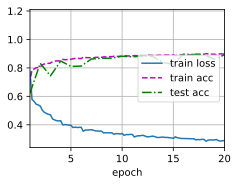

In [57]:
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

### 3.我们是否需要在每个层中进行批量规范化？尝试一下？

loss 0.196, train acc 0.927, test acc 0.890
55817.6 examples/sec 
total time 21.4986sec on cuda


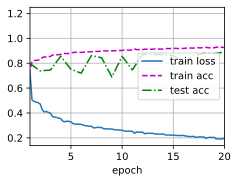

In [73]:
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10),
)
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

loss 0.209, train acc 0.921, test acc 0.862
57274.3 examples/sec 
total time 20.9518sec on cuda


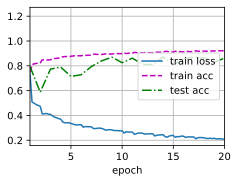

In [63]:
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5),  nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10),
)
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

loss 0.209, train acc 0.922, test acc 0.851
56803.2 examples/sec 
total time 21.1256sec on cuda


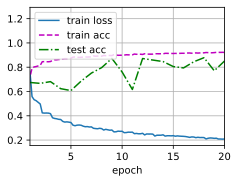

In [67]:
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10),
)
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

loss 0.210, train acc 0.921, test acc 0.848
56905.7 examples/sec 
total time 21.0875sec on cuda


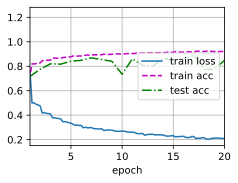

In [70]:
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10),
)
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

loss 0.213, train acc 0.922, test acc 0.878
57697.8 examples/sec 
total time 20.7980sec on cuda


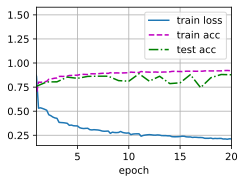

In [72]:
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10),
)
device=torch.device('cuda')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

去掉卷积层的BN会导致前几轮test_acc很低,就算到后面也是波动很大.  而去掉全连接层后的BN貌似训练效果会更好一些,test_acc的波动会小一些.

### 4.观察分析参数 gamma 和 beta

loss 0.201, train acc 0.926, test acc 0.862
7717.1 examples/sec 
total time 155.4984sec on cpu


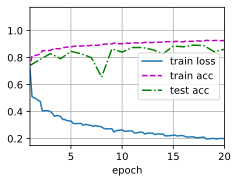

In [7]:
net=nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10),
)
device=torch.device('cpu')
lr=1.0
num_epochs=20
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

In [8]:
list(net[1].named_parameters())

[('weight',
  Parameter containing:
  tensor([3.6983, 2.6122, 3.4067, 3.4423, 5.4077, 3.3841], requires_grad=True)),
 ('bias',
  Parameter containing:
  tensor([ 1.7236, -2.0355, -3.4667, -3.6313, -2.4113,  1.3539],
         requires_grad=True))]

In [13]:
s=dict(net[5].named_parameters())
s['weight'].data

tensor([2.1468, 2.9293, 2.6006, 2.1611, 2.6623, 2.1185, 1.8536, 2.4857, 1.6211,
        1.5603, 1.6227, 2.6495, 2.4701, 1.5102, 1.6624, 0.5636])

In [81]:
list(net[10].named_parameters()),net[10].__class__.__name__

([('weight',
   Parameter containing:
   tensor([1.4556, 1.4393, 1.3956, 2.0624, 1.4020, 1.4102, 1.1748, 1.0854, 1.6058,
           1.2027, 1.9425, 1.3427, 1.4834, 1.4206, 1.1312, 1.9737, 1.3430, 1.7859,
           1.4550, 1.3114, 1.1861, 1.6008, 1.3554, 1.1442, 1.1194, 1.2990, 2.4991,
           1.3318, 1.0411, 1.5115, 1.4727, 1.3469, 1.2628, 1.2886, 1.1201, 1.1763,
           0.9995, 1.0869, 1.8045, 1.3139, 2.1686, 1.7664, 1.4787, 1.3315, 1.8498,
           1.9259, 1.1010, 2.1233, 1.7631, 0.9789, 1.9289, 1.3243, 1.4083, 1.7452,
           1.1493, 1.5772, 1.1248, 1.2485, 1.7682, 1.2033, 2.5895, 1.8341, 1.0356,
           1.4921, 1.1764, 1.5683, 0.9725, 1.3748, 0.9254, 1.3936, 1.2251, 1.3568,
           1.5395, 1.0550, 1.5538, 1.0969, 1.9365, 1.2750, 2.1009, 1.4222, 1.3397,
           1.1178, 1.1939, 1.7580, 1.2502, 1.2516, 1.0080, 1.3325, 1.1350, 1.5248,
           1.3996, 1.3202, 1.6150, 1.2916, 1.2612, 1.4618, 1.2657, 1.6520, 1.4177,
           1.2909, 1.2908, 1.4302, 1.1447, 1.1858

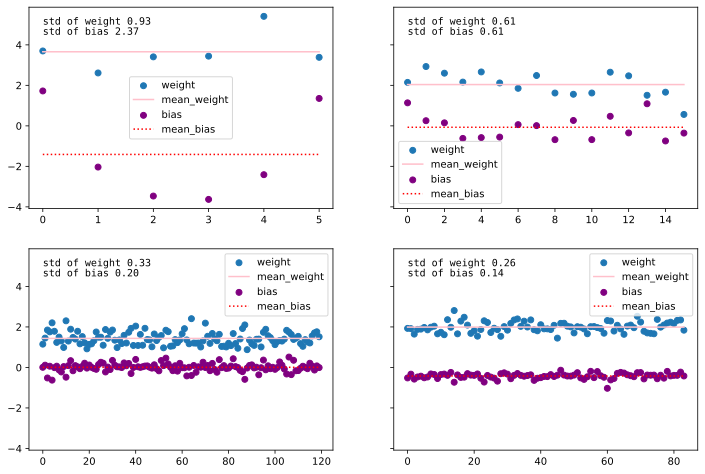

In [69]:
import matplotlib.pyplot as plt
%matplotlib inline
import math
count=0
weight=[]
bias=[]
for layer in net:
    if isinstance(layer,(nn.BatchNorm1d, nn.BatchNorm2d)):
        count+=1
        layer_dict=dict(layer.named_parameters())
        weight.append(layer_dict['weight'].data)
        bias.append(layer_dict['bias'].data)
fig,ax=plt.subplots(math.ceil(count/2),2,figsize=(6*2,4*math.ceil(count/2)),sharey=True,)
for i in range(count):
    weight_i=weight[i]
    bias_i=bias[i]
    x=torch.arange(weight_i.shape[0])
    ax[i//2,i%2].scatter(x=x,y=weight_i,label='weight')
    ax[i//2,i%2].plot(weight_i.mean().expand(weight_i.shape[0]),color='pink',label='mean_weight')
    ax[i//2,i%2].scatter(x=x,y=bias_i,color='purple',label='bias')
    ax[i//2,i%2].plot(bias_i.mean().expand(bias_i.shape[0]),color='red',linestyle='dotted',label='mean_bias')
    ax[i//2,i%2].text(0,5, f"std of weight {weight_i.std():.2f}",family="monospace", fontsize=10)
    ax[i//2,i%2].text(0,4.5, f"std of bias {bias_i.std():.2f}",family="monospace", fontsize=10)
    
    ax[i//2,i%2].legend()

[注]:fig,ax=plt.subplots(1,count,figsize=(3*count,2))\\x=torch.arange(weight[0].shape[0])\\ax[0].scatter(x=x,y=weight[0],axes=ax[0])#这里选择子图时和pandas略有不同


随着层的深入,方差变小,变得集中